Image Detection & Classification for Beginners
Dataset: Cats vs Dogs Image Dataset (Kaggle)

Goal: Build a Convolutional Neural Network (CNN) to classify images as either Cat or Dog.

Import Necessary Libraries

In [ ]:
# Cell 1: Import core libraries
import os
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers

print("TensorFlow Version:", tf.__version__)

TensorFlow Version: 2.18.0


In [ ]:
# Cell 2: Safe Dataset Sanitization (Windows-Compatible)
import os
from PIL import Image

# Path to dataset folder
dataset_dir = r"PetImages"  # Adjust if your folder path is different

clean_count = 0
removed_count = 0

for root, _, files in os.walk(dataset_dir):
  for file in files:
    if file.lower().endswith(('.jpg', '.jpeg', '.png')):
      file_path = os.path.join(root, file)

      # 1. Try reading and converting the image safely
      try:
        img = Image.open(file_path)
        img.verify()  # Verify image integrity first
        img.close()  # EXPLICITLY CLOSE to release Windows file lock

        # Re-open briefly to convert non-RGB images
        img = Image.open(file_path)
        if img.mode != 'RGB':
          rgb_img = img.convert('RGB')
          img.close()  # Close original file before saving
          rgb_img.save(file_path)
          clean_count += 1
        else:
          img.close()

      # 2. Handle corrupt/locked files safely
      except Exception as e:
        # Ensure file handle is closed before deletion
        try:
          img.close()
        except NameError:
          pass

        # Now remove the corrupted file cleanly
        try:
          if os.path.exists(file_path):
            os.remove(file_path)
            removed_count += 1
        except PermissionError:
          print(f"Skipped locked file: {file_path}")

print(
    f"Sanitization Complete! Converted {clean_count} image(s) to RGB, and"
    f" removed {removed_count} corrupt image(s)."
)

C:\Users\user\anaconda3\envs\nielitai\Lib\site-packages\PIL\TiffImagePlugin.py:949: UserWarning: Truncated File Read
  warnings.warn(str(msg))


Sanitization Complete! Converted 64 image(s) to RGB, and removed 0 corrupt image(s).


Load and Preprocess Images Automatically
Instead of writing complex image-loading loops, we use image_dataset_from_directory(). It automatically reads folder names (cats and dogs) as labels!

In [ ]:
# Cell 3: Load data with Keras image loader
IMAGE_SIZE = (128, 128)
BATCH_SIZE = 32

train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

class_names = train_ds.class_names
print("Classes detected:", class_names)

Found 24998 files belonging to 2 classes.
Using 19999 files for training.
Found 24998 files belonging to 2 classes.
Using 4999 files for validation.
Classes detected: ['Cat', 'Dog']


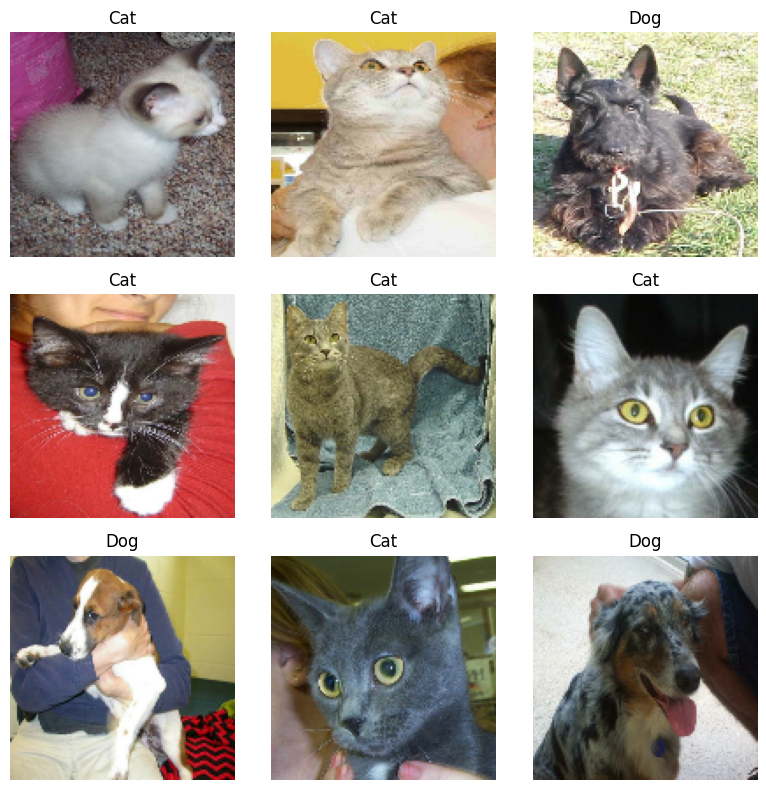

In [ ]:
# Cell 4: View 9 sample images from the dataset
plt.figure(figsize=(8, 8))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
    plt.title(class_names[labels[i]])
    plt.axis("off")
plt.tight_layout()
plt.show()

In [ ]:
#cell 5a

deleted_files = 0

for root, _, files in os.walk(dataset_dir):
  for file in files:
    if file.lower().endswith(('.jpg', '.jpeg', '.png', '.bmp')):
      file_path = os.path.join(root, file)

      try:
        # Read raw binary file
        image_bytes = tf.io.read_file(file_path)

        # Attempt decoding with TensorFlow's decoder
        decoded_img = tf.io.decode_image(image_bytes, expand_animations=False)

        # Ensure image has 1, 3, or 4 channels
        num_channels = decoded_img.shape[-1]
        if num_channels not in [1, 3, 4]:
          print(f"Invalid channels ({num_channels}): {file_path}")
          os.remove(file_path)
          deleted_files += 1

      except Exception as e:
        # If TensorFlow fails to decode, delete the corrupted file
        print(f"Corrupt image removed: {file_path}")
        try:
          os.remove(file_path)
          deleted_files += 1
        except Exception as delete_error:
          print(f"Failed to delete {file_path}: {delete_error}")

print(
    f"\nDataset Cleaned! Successfully removed {deleted_files} unreadable/invalid"
    " image(s)."
)

Corrupt image removed: PetImages\Cat\10404.jpg
Corrupt image removed: PetImages\Cat\4351.jpg
Corrupt image removed: PetImages\Dog\11233.jpg
Corrupt image removed: PetImages\Dog\11912.jpg
Corrupt image removed: PetImages\Dog\2317.jpg
Corrupt image removed: PetImages\Dog\2494.jpg
Corrupt image removed: PetImages\Dog\9500.jpg

Dataset Cleaned! Successfully removed 7 unreadable/invalid image(s).


In [ ]:
# Change from 128x128 to 64x64 for much faster CPU training
IMAGE_SIZE = (64, 64)
BATCH_SIZE = 64  # Process 64 images at once 

train_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="training",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

val_ds = keras.utils.image_dataset_from_directory(
    dataset_dir,
    validation_split=0.2,
    subset="validation",
    seed=42,
    image_size=IMAGE_SIZE,
    batch_size=BATCH_SIZE,
)

Found 24991 files belonging to 2 classes.
Using 19993 files for training.
Found 24991 files belonging to 2 classes.
Using 4998 files for validation.


In [ ]:
# Cell 5: Create a simple Convolutional Neural Network (CNN)
model = keras.Sequential([
    keras.Input(shape=(128, 128, 3)),
    # Rescale pixel values from [0, 255] to [0, 1]
    layers.Rescaling(1.0 / 255),
    # First Conv Block
    layers.Conv2D(32, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    # Second Conv Block
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    # Third Conv Block
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D(2, 2),
    # Dense Classifier
    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(1, activation='sigmoid'),  # Output 0 (Cat) or 1 (Dog)
])

model.summary()

Model: "sequential_2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ rescaling_2 (Rescaling)              │ (None, 128, 128, 3)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_6 (Conv2D)                    │ (None, 126, 126, 32)        │             896 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_6 (MaxPooling2D)       │ (None, 63, 63, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_7 (Conv2D)                    │ (None, 61, 61, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_7 (MaxPooling2D)       │ (None, 30, 30, 64)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_8 (Conv2D)                    │ (None, 28, 28, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_8 (MaxPooling2D)       │ (None, 14, 14, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_2 (Flatten)                  │ (None, 25088)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_4 (Dense)                      │ (None, 64)                  │       1,605,696 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_5 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 1,699,009 (6.48 MB)

 Trainable params: 1,699,009 (6.48 MB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
# Cell 6: Compile and train
model.compile(
    optimizer='adam', loss='binary_crossentropy', metrics=['accuracy']
)

# Train for 8 epochs
#epochs = 8
#history = model.fit(train_ds, validation_data=val_ds, epochs=epochs)

Epoch 1/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 308ms/step - accuracy: 0.5883 - loss: 0.6634 - val_accuracy: 0.7561 - val_loss: 0.5093
Epoch 2/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 182s 292ms/step - accuracy: 0.7558 - loss: 0.5074 - val_accuracy: 0.7943 - val_loss: 0.4438
Epoch 3/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 194s 310ms/step - accuracy: 0.8063 - loss: 0.4173 - val_accuracy: 0.8059 - val_loss: 0.4313
Epoch 4/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 193s 309ms/step - accuracy: 0.8434 - loss: 0.3480 - val_accuracy: 0.8339 - val_loss: 0.3818
Epoch 5/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 206s 330ms/step - accuracy: 0.8873 - loss: 0.2661 - val_accuracy: 0.8373 - val_loss: 0.4292
Epoch 6/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 196s 314ms/step - accuracy: 0.9178 - loss: 0.1933 - val_accuracy: 0.8207 - val_loss: 0.6067
Epoch 7/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 199s 318ms/step - accuracy: 0.9496 - loss: 0.1290 - val_accuracy: 0.8331 - val_loss: 0.6817
Epoch 8/8
625/625 ━━━━━━━━━━━━━━━━━━━━ 184s 294ms/step - accuracy: 0.9643 - loss: 0

In [ ]:
# Use only 50 batches (~1,600 training images total)
train_ds_fast = train_ds.take(50)
val_ds_fast = val_ds.take(10)

# Train on the subset
history = model.fit(train_ds_fast, validation_data=val_ds_fast, epochs=5)

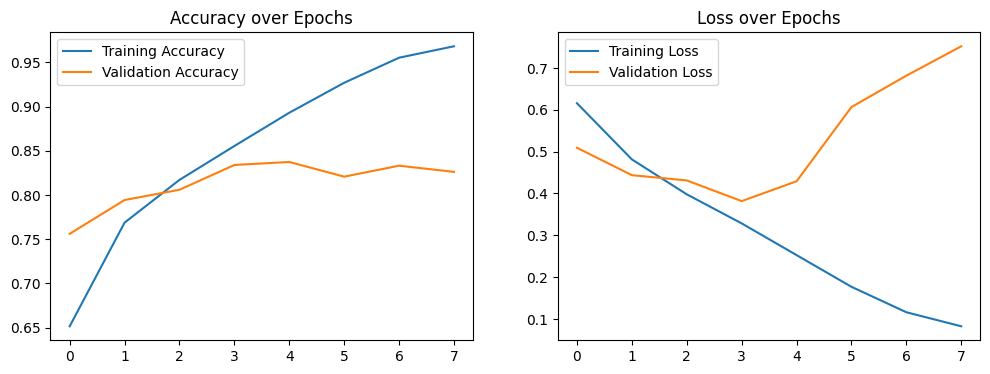

In [ ]:
# Cell 7: Plot training graphs
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']
loss = history.history['loss']
val_loss = history.history['val_loss']

plt.figure(figsize=(12, 4))

plt.subplot(1, 2, 1)
plt.plot(acc, label='Training Accuracy')
plt.plot(val_acc, label='Validation Accuracy')
plt.title('Accuracy over Epochs')
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(loss, label='Training Loss')
plt.plot(val_loss, label='Validation Loss')
plt.title('Loss over Epochs')
plt.legend()

plt.show()

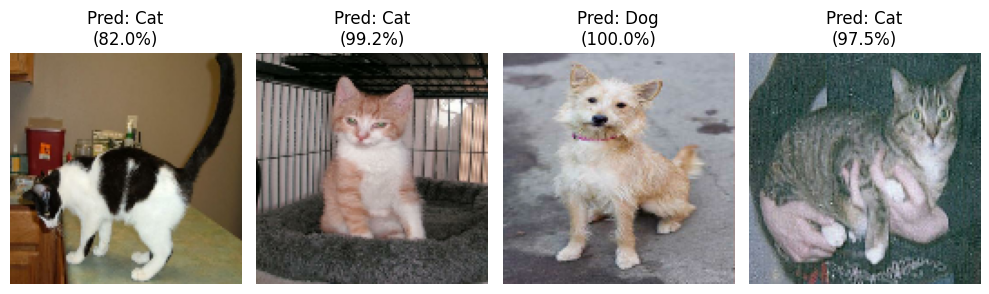

In [ ]:
# Cell 8: Test predictions on 4 sample validation images
for images, labels in val_ds.take(1):
  plt.figure(figsize=(10, 5))
  for i in range(4):
    img = images[i]
    # Add batch dimension to pass into model
    img_array = tf.expand_dims(img, 0)
    pred_prob = model.predict(img_array, verbose=0)[0][0]

    predicted_label = class_names[1] if pred_prob >= 0.5 else class_names[0]
    confidence = pred_prob if pred_prob >= 0.5 else (1 - pred_prob)

    ax = plt.subplot(1, 4, i + 1)
    plt.imshow(img.numpy().astype("uint8"))
    plt.title(f"Pred: {predicted_label}\n({confidence * 100:.1f}%)")
    plt.axis("off")
  plt.tight_layout()
  plt.show()